# Customer Churn Prediction

## 1. Import Libraries

In [7]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [8]:
# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')



# 3. Data Preprocessing

## 3.1 Dataset Overview

In [9]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Check dataset dimensions
df.shape

(7043, 21)

In [11]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3.2 Missing Values

In [12]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3.3 Duplicate Records

In [13]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

### 3.4 Data Cleaning

In [14]:
# Convert TotalCharges to numeric datatype

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
# Remove rows containing missing values
df.dropna(inplace=True)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [18]:
# Drop customerID as it does not contribute to the prediction
df.drop('customerID', axis=1, inplace=True)

### 3.5 Encoding Categorical Features

In [19]:
# Convert categorical features to numerical features using one-hot encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [20]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [21]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService_No  

In [22]:
# Convert boolean columns to integer datatype
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService_No  

In [24]:
df.shape

(7032, 31)

In [25]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [26]:
# Check for missing values
df.isnull().sum()


SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [27]:

# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


### 3.6 Save Cleaned Dataset

In [29]:
# Save the cleaned dataset
df.to_csv(
    "Telco-Customer-Churn-Cleaned.csv",
    index=False
)

## 4. Exploratory Data Analysis

### 4.1 What percentage of customers have churned?

In [30]:
# Calculate churn percentage
churn_percentage = df["Churn_Yes"].value_counts(normalize=True) * 100

# Display percentages
print(f"No Churn Percentage: {churn_percentage[0]:.2f}%")
print(f"Churn Percentage: {churn_percentage[1]:.2f}%")

No Churn Percentage: 73.51%
Churn Percentage: 26.49%


### 4.2 Which contract type has the highest churn?

In [31]:
# Display contract-related columns
df.columns[df.columns.str.contains('Contract')]

Index(['Contract_One year', 'Contract_Two year'], dtype='str')

In [32]:
# Calculate churn rates by contract type
month_to_month_churn = df[
    (df["Contract_One year"] == 0) &
    (df["Contract_Two year"] == 0)
]["Churn_Yes"].mean() * 100

one_year_churn = df[
    df["Contract_One year"] == 1
]["Churn_Yes"].mean() * 100

two_year_churn = df[
    df["Contract_Two year"] == 1
]["Churn_Yes"].mean() * 100

In [33]:
print(f"Month-to-Month Contract Churn Rate: {month_to_month_churn:.2f}%")
print(f"One Year Contract Churn Rate: {one_year_churn:.2f}%")
print(f"Two Year Contract Churn Rate: {two_year_churn:.2f}%")

Month-to-Month Contract Churn Rate: 42.64%
One Year Contract Churn Rate: 11.28%
Two Year Contract Churn Rate: 2.85%


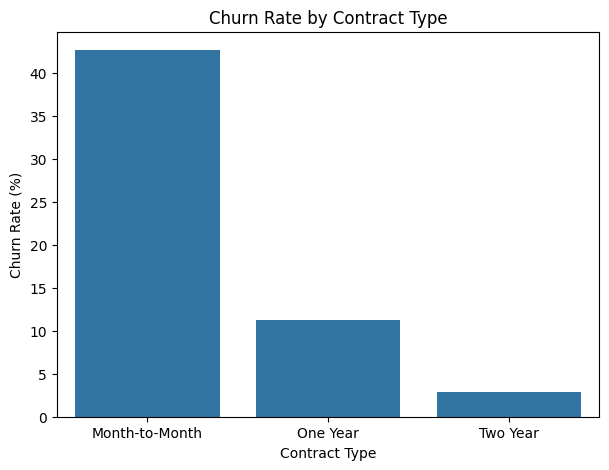

In [ ]:
# Create a dataframe for visualization
contract_churn = pd.DataFrame({
    "Contract Type": [
        "Month-to-Month",
        "One Year",
        "Two Year"
    ],
    "Churn Rate": [
        month_to_month_churn,
        one_year_churn,
        two_year_churn
    ]
})

# Visualize churn rate by contract type
plt.figure(figsize=(7,5))

sns.barplot(
    data=contract_churn,
    x="Contract Type",
    y="Churn Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.savefig("images/churn_rate_by_contract.png", bbox_inches="tight")
plt.show()

### Observation

Customers with month-to-month contracts exhibit the highest churn rate (42.64%), while customers with two-year contracts exhibit the lowest churn rate (2.85%). Long-term contracts are associated with better customer retention.

#### 4.3 Does MonthlyCharges impact churn?

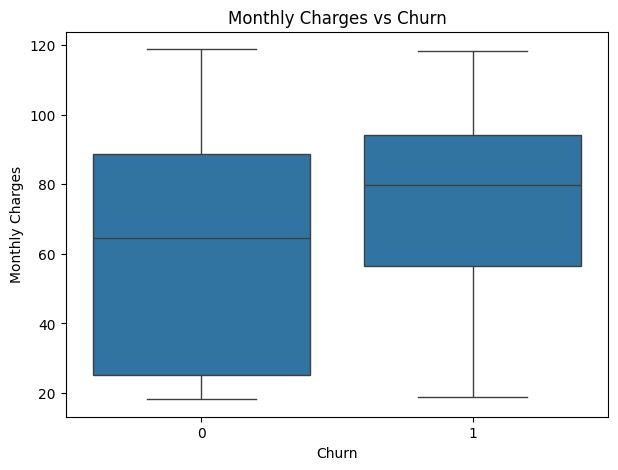

In [ ]:
# Visualize Monthly Charges by churn status
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn_Yes",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.savefig("images/monthly_charges_vs_churn.png", bbox_inches="tight")
plt.show()

### 4.4 Which features correlate most with churn?

In [36]:
# Calculate feature correlations with churn
churn_corr = df.corr()["Churn_Yes"].sort_values(ascending=False)

# Display correlations
print(churn_corr)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.307612
PaymentMethod_Electronic check           0.301079
MonthlyCharges                           0.194008
PaperlessBilling_Yes                     0.190518
SeniorCitizen                            0.151270
StreamingTV_Yes                          0.065058
StreamingMovies_Yes                      0.062670
MultipleLines_Yes                        0.041888
PhoneService_Yes                         0.011072
gender_Male                             -0.008694
MultipleLines_No phone service          -0.011072
DeviceProtection_Yes                    -0.064978
OnlineBackup_Yes                        -0.081145
PaymentMethod_Mailed check              -0.091649
PaymentMethod_Credit card (automatic)   -0.134052
Partner_Yes                             -0.148670
Dependents_Yes                          -0.162366
TechSupport_Yes                         -0.163980
OnlineSecurity_Yes                      -0.170565


##### Top 10 Correlated Features

In [37]:
# Display top 10 correlations with churn
print(churn_corr.head(10))

Churn_Yes                         1.000000
InternetService_Fiber optic       0.307612
PaymentMethod_Electronic check    0.301079
MonthlyCharges                    0.194008
PaperlessBilling_Yes              0.190518
SeniorCitizen                     0.151270
StreamingTV_Yes                   0.065058
StreamingMovies_Yes               0.062670
MultipleLines_Yes                 0.041888
PhoneService_Yes                  0.011072
Name: Churn_Yes, dtype: float64


#### Bottom 10 Correlations

In [38]:
# Display bottom 10 correlations with churn
print(churn_corr.tail(10))

TotalCharges                           -0.198362
OnlineSecurity_No internet service     -0.228220
StreamingMovies_No internet service    -0.228220
OnlineBackup_No internet service       -0.228220
InternetService_No                     -0.228220
TechSupport_No internet service        -0.228220
DeviceProtection_No internet service   -0.228220
StreamingTV_No internet service        -0.228220
Contract_Two year                      -0.301375
tenure                                 -0.353339
Name: Churn_Yes, dtype: float64


#### Correlation Heatmap

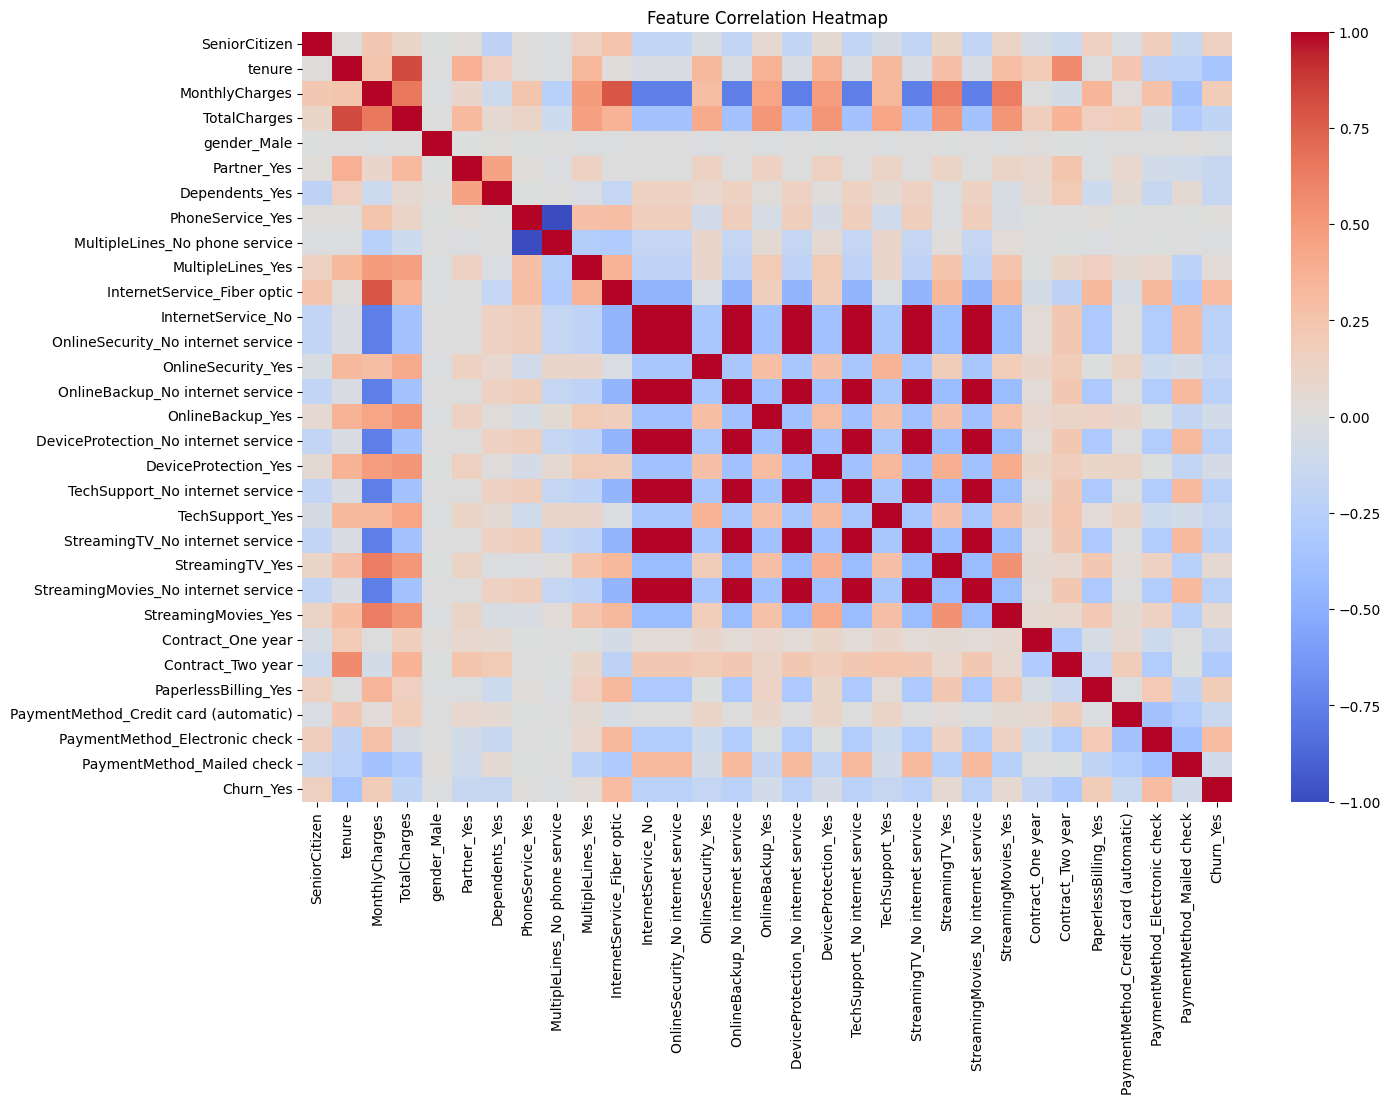

In [ ]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Visualize correlation matrix
plt.figure(figsize=(15,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.savefig("images/feature_correlation.png", bbox_inches="tight")
plt.show()

### Observations
##### Typical findings are:
- "Customers with longer tenure are less likely to churn."
- "Customers with two-year contracts have lower churn."
- "Higher monthly charges are associated with higher churn"
- "Fiber optic internet users tend to exhibit higher churn."
                         